<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html hw3.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

# PHY321: Classical Mechanics 1
**Homework 3, due February 4**

Date: **Jan 31, 2022**

### Practicalities about  homeworks and projects

1. You can work in groups (optimal groups are often 2-3 people) or by yourself. If you work as a group you can hand in one answer only if you wish. **Remember to write your name(s)**!

2. Homeworks are available ten days  before the deadline. 

3. How do I(we)  hand in?  You can hand in the paper and pencil exercises as a  scanned document. For this homework this applies to exercises 1-5. Alternatively, you can hand in everything (if you are ok with typing mathematical formulae using say Latex) as a jupyter notebook at D2L. The numerical exercise(s) (exercise 6 here) should always be handed in as a jupyter notebook by the deadline at D2L.

### Introduction to homework 3

This week's sets of classical pen and paper and computational
exercises deal with the motion of different objects under the
influence of various forces. The relevant reading background is
1. chapter 2 of Taylor (there are many good examples there) and

2. chapters 5-7 of Malthe-Sørenssen.

In both textbooks there are many nice worked out
examples. Malthe-Sørenssen's text contains also several coding
examples you may find useful.

There are several pedagogical aims we have in mind with these exercises:
1. Get practice in setting up and analyzing a physical problem, finding the forces and the relevant equations to solve;

2. Analyze the results and ask yourself whether they make sense or not;

3. Finding analytical solutions to problems if possible and compare these with numerical results. This teaches us also how to understand errors in numerical calculations;

4. Being able to solve (in mechanics these are the most common types of equations) numerically ordinary differential equations and compare the solutions where possible with analytical solutions;

5. Getting used to studying physical problems using all possible tools, from paper and pencil to numerical solutions;

6. Then analyze the results and ask yourself whether they make sense or not.

The above steps outline important elements of our understanding of the
scientific method. Furthermore, there are also explicit coding skills
we aim at such as setting up arrays, solving differential equations
numerically and plotting your results.  Coding practice is also an
important aspect. The more we practice the better we get (hopefully).
From a numerical mathematics point of view, we will solve the differential
equations using Euler's method (forward Euler).

The code we will develop can be reused as a basis for coming homeworks. We can
also extend the numerical solver we write here to include other methods (later) like
the modified Euler method (Euler-Cromer, midpoint Euler) and more
advanced methods like the family of Runge-Kutta methods and the Velocity-Verlet method.

At the end of this course, we will thus have developed a larger code
(or set of codes) which will allow us to study different numerical
methods (integration and differential equations) as well as being able
to study different physical systems. Combined with analytical skills,
the hope is that this can allow us to explore interesting and
realistic physics problems. By doing so, the hope is that can lead to
deeper insights about the laws of motion which govern a system.

And hopefully you can reuse many of the above solvers in other courses (our ideal).

### Exercise 1 (20 pt), Electron moving into an electric field

An electron is sent through a varying electrical
field. Initially, the electron is moving in the $x$-direction with a velocity
$v_x = 100$ m/s. The electron enters the field when it passes the origin. The field
varies with time, causing an acceleration of the electron that varies in time

$$
\boldsymbol{a}(t)=\left(−20 \mathrm{m/s}^2 −10\mathrm{m/s}^3t\right) \boldsymbol{e}_y
$$

* 1a (4pt) Find the velocity as a function of time for the electron.

* 1b (4pt)  Find the position as a function of time for the electron.

The field is only acting inside a box of length $L = 2m$.
* 1c (4pt)  How long time is the electron inside the field?

* 1d (4pt)  What is the displacement in the $y$-direction when the electron leaves the box. (We call this the deflection of the electron).

* 1e (4pt)  Find the angle the velocity vector forms with the horizontal axis as the electron leaves the box.

### Exercise 2 (10 pt), Drag force

Taylor exercise 2.3

### Exercise 3 (10 pt), Falling object

Taylor exercise 2.6

### Exercise 4 (10 pt), and then a cyclist

Taylor exercise 2.26

### Exercise 5 (10 pt), back to a falling ball and preparing for the numerical exercise

**Useful material: Malthe-Sørenssen chapter 7.5 and Taylor chapter 2.4.**

In this example we study the motion of an object subject to a constant force, a velocity dependent
force. We will  reuse the code we develop here in homework 4 for a position-dependent force.

Here we limit ourselves to a ball that is thrown from a height $h$
above the ground with an initial velocity
$\boldsymbol{v}_0$ at time $t=t_0$. We assume the air resistance is proportional  to the square velocity, Together with the gravitational force these are the forces acting on our system.
**Note that due to the specific velocity dependence, we cannot find an analytical solution for motion in the $x$ and $y$ directions, see the discussion in Taylor after eq. (2.61).**
In order to find an analytical solution we need to assume that the object is falling in the $y$-direction (negative direction) only. 

The position of the ball as function of time is  $\boldsymbol{r}(t)$ where $t$ is time.
 The position is measured with respect to a coordinate system with origin at the floor.

We assume we have an initial position $\boldsymbol{r}(t_0)=h\boldsymbol{e}_y$ and an initial velocity $\boldsymbol{v}_0=v_{x,0}\boldsymbol{e}_x+v_{y,0}\boldsymbol{e}_y$.

In this exercise we assume the system is influenced by the gravitational force

$$
\boldsymbol{G}=-mg\boldsymbol{e}_y
$$

and an air resistance given by a square law

$$
-Dv\boldsymbol{v}.
$$

The analytical expressions for velocity and position as functions of
time will be used to compare with the numerical results in exercise 6.

* 5a (3pt) Identify the forces acting on the ball and set up a diagram with the forces acting on the ball. Find the acceleration of the falling ball. 

* 5b (4pt) Assume now that the object is falling only in the $y$-direction (negative direction). Integrate the acceleration from an initial time $t_0$ to a final time $t$ and find the velocity. In Taylor equations (2.52) to (2.58) you will find a very good discussion of this.

* 5c (4pt) Find thereafter the position as function of time starting with an initial time $t_0$. Find the time it takes to hit the floor.  Here you will find it convenient to set the initial velocity in the $y$-direction to zero. Taylor equations (2.52)-(2.58) should contain all relevant information for solving this part as well.

We will use the above analytical results in our numerical calculations in exercise 6. The analytical solution in the $y$-direction only will serve as a test for our numerical solution.

### Exercise 6 (40pt), Numerical elements, solving exercise 5 numerically

**This exercise should be handed in as a jupyter-notebook** at D2L. Remember to write your name(s). 

Last week we:
1. Gained more practice with plotting in Python

2. Became familiar with arrays and representing vectors with such objects

This week we will:
1. Learn and utilize Euler's Method to find the position and the velocity

2. Compare analytical and computational solutions 

3. Add additional forces to our model

In [1]:
%matplotlib inline

# let's start by importing useful packages we are familiar with
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd
%matplotlib inline

We will choose the following values
1. mass $m=0.2$ kg

2. accelleration (gravity) $g=9.81$ m/s$^{2}$.

3. initial position is the height $h=2$ m

4. initial velocities $v_{x,0}=v_{y,0}=10$ m/s

Can you find a reasonable value for the drag coefficient $D$?
You need also to define an initial time and 
the step size $\Delta t$. We can define the step size $\Delta t$ as the difference between any
two neighboring values in time (time steps) that we analyze within
some range. It can be determined by dividing the interval we are
analyzing, which in our case is time $t_{\mathrm{final}}-t_0$, by the number of steps we
are taking $(N)$. This gives us a step size $\Delta t = \dfrac{t_{\mathrm{final}}-t_0}{N}$.

With these preliminaries we are now ready to plot our results from exercise 5.

* 6a (10pt) Set up arrays for time, velocity, acceleration and positions for the results from exercise 5. Define an initial and final time. Choose the final time to be the time when the ball hits the ground for the first time. Make a plot of the position and velocity as functions of time.  Here you could set the initial velocity in the $y$-direction to zero and use the result from exercise 5. Else you need to try different initial times using the result from exercise 5 as a starting guess.  It is not critical if you don't reach the ground when the initial velocity in the $y$-direction is not zero.

We move now to the numerical solution of the differential equations as discussed in the [lecture notes](https://mhjensen.github.io/Physics321/doc/pub/motion/html/motion.html) or Malthe-Sørenssen chapter 7.5.
Let us remind ourselves about  Euler's Method.

Suppose we know $f(t)$ and its derivative $f'(t)$. To find $f(t+\Delta t)$ at the next step, $t+\Delta t$,
we can consider the Taylor expansion:

$f(t+\Delta t) = f(t) + \dfrac{(\Delta t)f'(t)}{1!} + \dfrac{(\Delta t)^2f''(t)}{2!} + ...$

If we ignore the $f''$ term and higher derivatives, we obtain

$f(t+\Delta t) \approx f(t) + (\Delta t)f'(t)$.

This approximation is the basis of Euler's method, and the Taylor
expansion suggests that it will have errors of $O(\Delta t^2)$.  Thus, one
would expect it to work better, the smaller the step size $h$ that you
use. In our case the step size is $\Delta t$. 

In setting up our code we need to

1. Define and obtain all initial values, constants, and time to be analyzed with step sizes as done above (you can use the same values)

2. Calculate the velocity using $v_{i+1} = v_{i} + (\Delta t)*a_{i}$

3. Calculate the position using $pos_{i+1} = r_{i} + (\Delta t)*v_{i}$

4. Calculate the new acceleration $a_{i+1}$.

5. Repeat steps 2-4 for all time steps within a loop.

* 6b (20 pt) Write a code which implements Euler's method and compute numerically and plot the position and velocity as functions of time for various values of $\Delta t$. Comment your results.

* 6c (10pt) Compare your numerically obtained positions and velocities with the analytical results from exercise 5. In order to do this, you need to take out the motion in the $x$-direction. Comment again your results.

**6a)** With initial $v_x = v_y = 0 m/s$ and $x_0 = 0m, y_0 = 2m$

Calculated $t_{final} = 0.641 s$ using the expression obtained in exercise 5.

Text(0.5, 0, 't (s)')

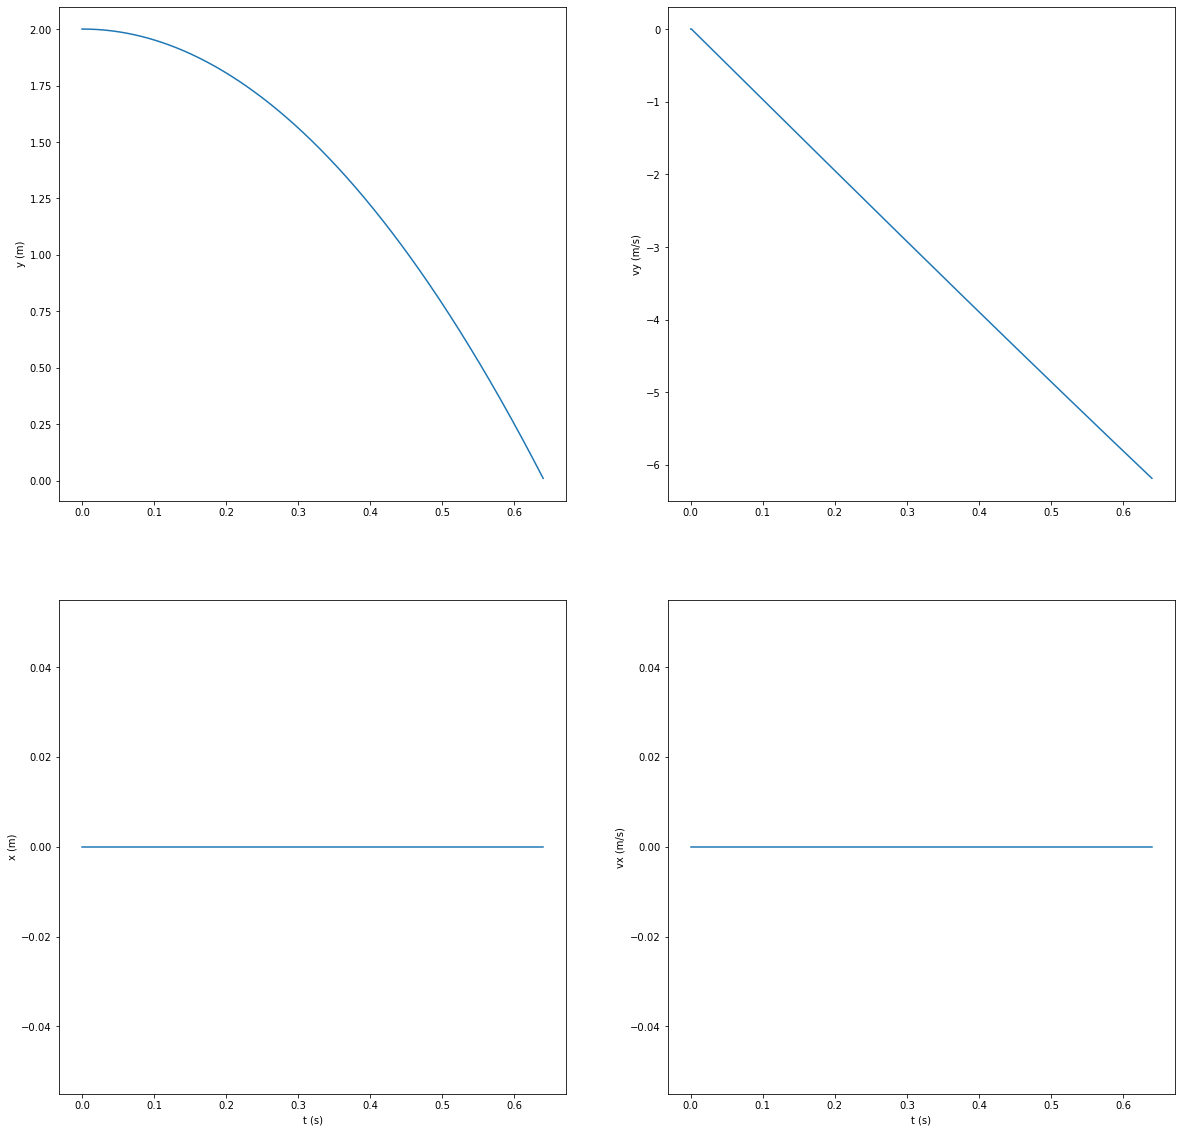

In [2]:
D = 0.002
m = 0.2
delta_t = 0.001
g = 9.81
tfinal = 0.641
n = int(tfinal/delta_t)
v_ter = np.sqrt(m*g/D)
t = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)
x = np.zeros(n)
y = np.zeros(n)
vx[0]=0
vy[0]=0
y[0]=2
t[0]=0
x[0]=0
for i in range(len(t)-1):
    vx[i+1] = vx[0]
    vy[i+1] = -v_ter*np.tanh(g*t[i]/v_ter)
    x[i+1] = x[0]
    y[i+1] = y[0]-((v_ter**2/g))*np.log(np.cosh(g*t[i]/v_ter))
    t[i+1] = t[i]+delta_t
fig, axes = plt.subplots(2,2)
fig.set_size_inches(20,20)
axes[0][0].plot(t, y)
axes[0][0].set_ylabel('y (m)')
axes[0][1].plot(t, vy)
axes[0][1].set_ylabel('vy (m/s)')
axes[1][0].plot(t, x)
axes[1][0].set_ylabel('x (m)')
axes[1][0].set_xlabel('t (s)')
axes[1][1].plot(t, vx)
axes[1][1].set_ylabel('vx (m/s)')
axes[1][1].set_xlabel('t (s)')

**6b)** With initial $v_x = v_y = 10 m/s$ and initial $x=0m, y=2m$ as mentioned above and $\Delta t = 0.001s$

Text(0.5, 0, 't (s)')

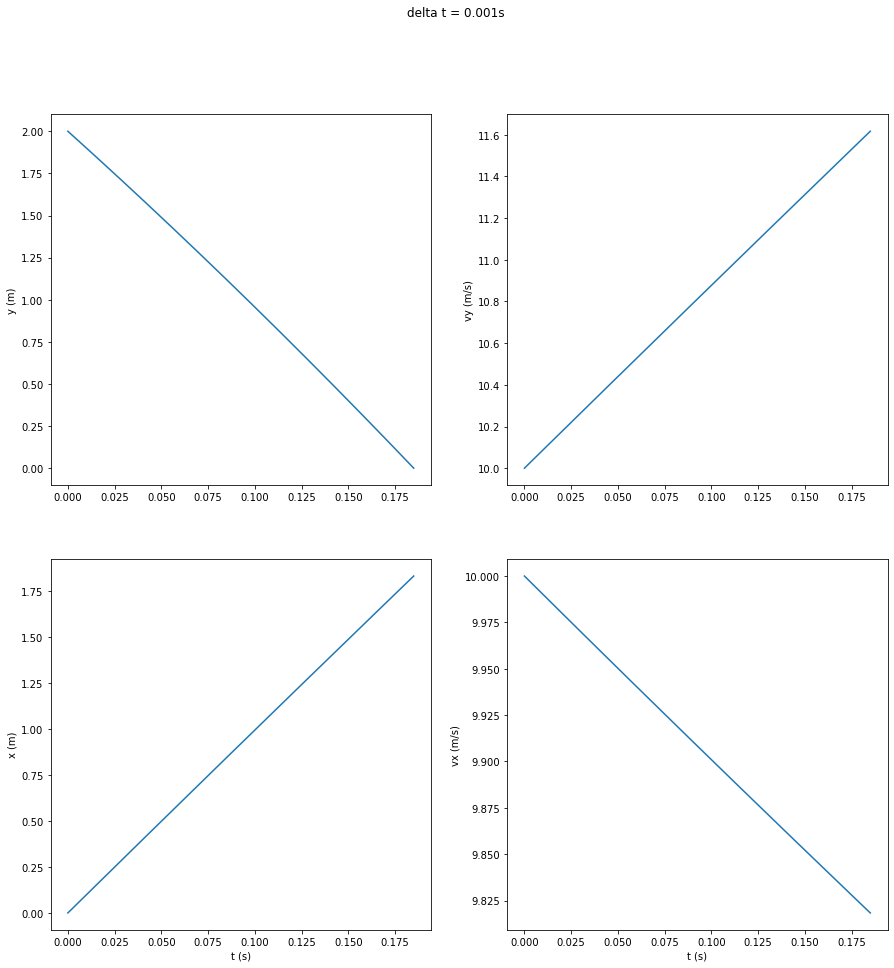

In [3]:
D = 0.002
m = 0.2
delta_t = 0.001
g = 9.81
tfinal = 0.186
n = int(tfinal/delta_t)
v_ter = np.sqrt(m*g/D)
t = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)
x = np.zeros(n)
y = np.zeros(n)
y_analytic = np.zeros(n)
vx[0]=10
vy[0]=10
y[0]=2
y_analytic[0]=2
x[0]=0
v = []
v.append(10)
for i in range(n-1):
    ax = -D/m*vx[i]*np.sqrt(vx[i]**2+vy[i+1]**2)
    ay = -D/m*vy[i]*np.sqrt(vx[i]**2+vy[i+1]**2)+g
    vx[i+1] = vx[i]+delta_t*ax
    vy[i+1] = vy[i]+delta_t*ay
    x[i+1] = x[i]+delta_t*vx[i]
    y[i+1] = y[i]-delta_t*vy[i]
    t[i+1] = t[i]+delta_t
    y_analytic[i] = y[0]-((v_ter**2/g))*np.log(np.cosh(g*t[i]/v_ter))-vy[0]*t[i]
    if (y[i+1]<0):
        break
fig, axes = plt.subplots(2,2)
fig.set_size_inches(15,15)
fig.suptitle('delta t = 0.001s')
axes[0][0].plot(t, y)
axes[0][0].set_ylabel('y (m)')
axes[0][1].plot(t, vy)
axes[0][1].set_ylabel('vy (m/s)')
axes[1][0].plot(t, x)
axes[1][0].set_ylabel('x (m)')
axes[1][0].set_xlabel('t (s)')
axes[1][1].plot(t, vx)
axes[1][1].set_ylabel('vx (m/s)')
axes[1][1].set_xlabel('t (s)')

With initial $v_x = v_y = 10 m/s$ and initial $x=0m, y=2m$ as mentioned above and $\Delta t = 0.0001s$

Text(0.5, 0, 't (s)')

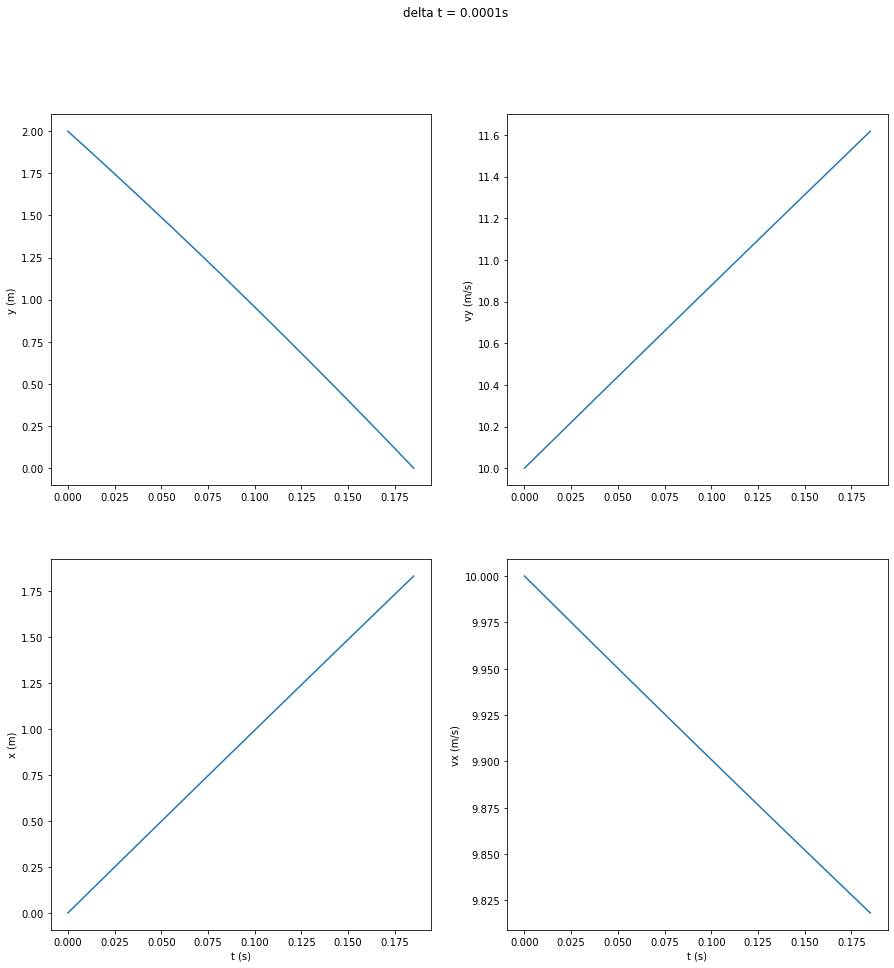

In [4]:
D = 0.002
m = 0.2
delta_t = 0.0001
g = 9.81
tfinal = 0.1853
n = int(tfinal/delta_t)
v_ter = np.sqrt(m*g/D)
t = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)
x = np.zeros(n)
y = np.zeros(n)
y_analytic = np.zeros(n)
vx[0]=10
vy[0]=10
y[0]=2
y_analytic[0]=2
x[0]=0
v = []
v.append(10)
for i in range(n-1):
    ax = -D/m*vx[i]*np.sqrt(vx[i]**2+vy[i+1]**2)
    ay = -D/m*vy[i]*np.sqrt(vx[i]**2+vy[i+1]**2)+g
    vx[i+1] = vx[i]+delta_t*ax
    vy[i+1] = vy[i]+delta_t*ay
    x[i+1] = x[i]+delta_t*vx[i]
    y[i+1] = y[i]-delta_t*vy[i]
    t[i+1] = t[i]+delta_t
    y_analytic[i] = y[0]-((v_ter**2/g))*np.log(np.cosh(g*t[i]/v_ter))-vy[0]*t[i]
    if (y[i+1]<0):
        break
fig, axes = plt.subplots(2,2)
fig.set_size_inches(15,15)
fig.suptitle('delta t = 0.0001s')
axes[0][0].plot(t, y)
axes[0][0].set_ylabel('y (m)')
axes[0][1].plot(t, vy)
axes[0][1].set_ylabel('vy (m/s)')
axes[1][0].plot(t, x)
axes[1][0].set_ylabel('x (m)')
axes[1][0].set_xlabel('t (s)')
axes[1][1].plot(t, vx)
axes[1][1].set_ylabel('vx (m/s)')
axes[1][1].set_xlabel('t (s)')

With initial $v_x = v_y = 10 m/s$ and initial $x=0m, y=2m$ as mentioned above and $\Delta t = 0.00001s$

Text(0.5, 0, 't (s)')

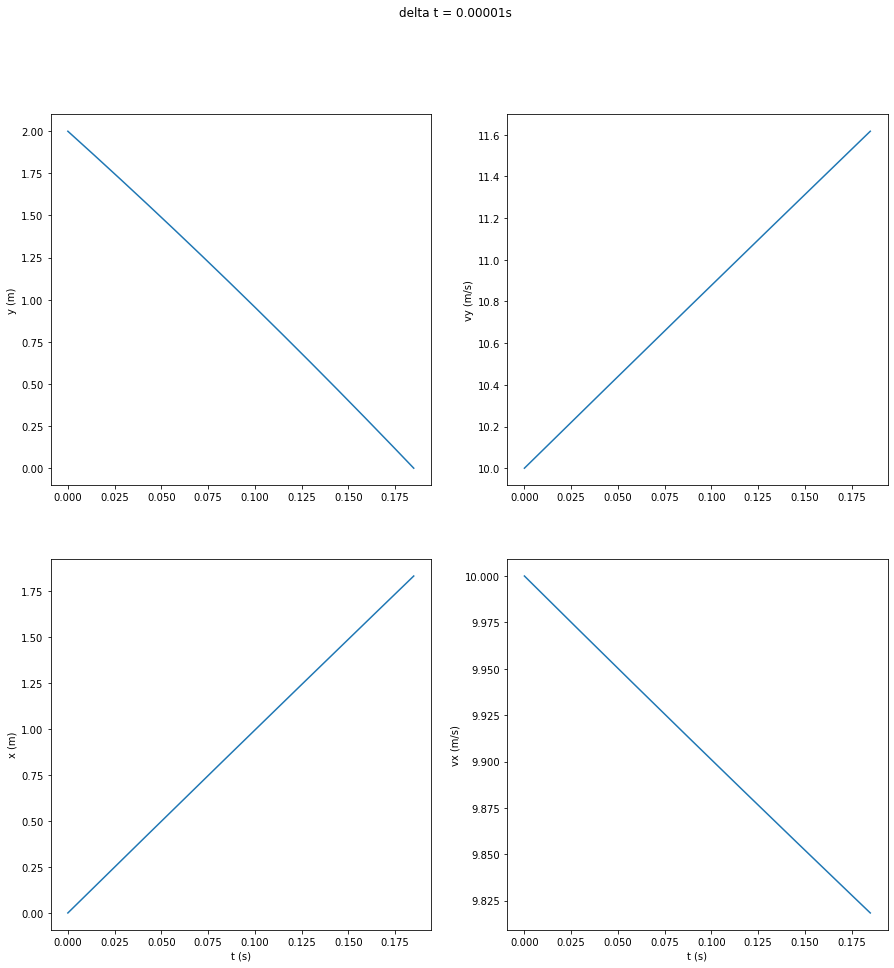

In [5]:
D = 0.002
m = 0.2
delta_t = 0.00001
g = 9.81
tfinal = 0.18502
n = int(tfinal/delta_t)
v_ter = np.sqrt(m*g/D)
t = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)
x = np.zeros(n)
y = np.zeros(n)
y_analytic = np.zeros(n)
vx[0]=10
vy[0]=10
y[0]=2
y_analytic[0]=2
x[0]=0
v = []
v.append(10)
for i in range(n-1):
    ax = -D/m*vx[i]*np.sqrt(vx[i]**2+vy[i+1]**2)
    ay = -D/m*vy[i]*np.sqrt(vx[i]**2+vy[i+1]**2)+g
    vx[i+1] = vx[i]+delta_t*ax
    vy[i+1] = vy[i]+delta_t*ay
    x[i+1] = x[i]+delta_t*vx[i]
    y[i+1] = y[i]-delta_t*vy[i]
    t[i+1] = t[i]+delta_t
    y_analytic[i] = y[0]-((v_ter**2/g))*np.log(np.cosh(g*t[i]/v_ter))-vy[0]*t[i]
    if (y[i+1]<0):
        break
fig, axes = plt.subplots(2,2)
fig.set_size_inches(15,15)
fig.suptitle('delta t = 0.00001s')
axes[0][0].plot(t, y)
axes[0][0].set_ylabel('y (m)')
axes[0][1].plot(t, vy)
axes[0][1].set_ylabel('vy (m/s)')
axes[1][0].plot(t, x)
axes[1][0].set_ylabel('x (m)')
axes[1][0].set_xlabel('t (s)')
axes[1][1].plot(t, vx)
axes[1][1].set_ylabel('vx (m/s)')
axes[1][1].set_xlabel('t (s)')

**As we take smaller values of $\Delta t$, $t_{final}$ keeps decreasing and starts becoming much more precise which does make sense as the number of significant figures is increasing. And from the plots, we can see that as $\Delta t$ decreases, the solution approaches the exact solution of the expression. However, when $\Delta t$ is too large, the solution might diverge from the exact solution, which highlights the importance of choosing a suitable $\Delta t$ for numerical integration.**

**6c)** Euler vs Analytic Results

Text(0.5, 1.0, 'Euler Method vs Analytical Method')

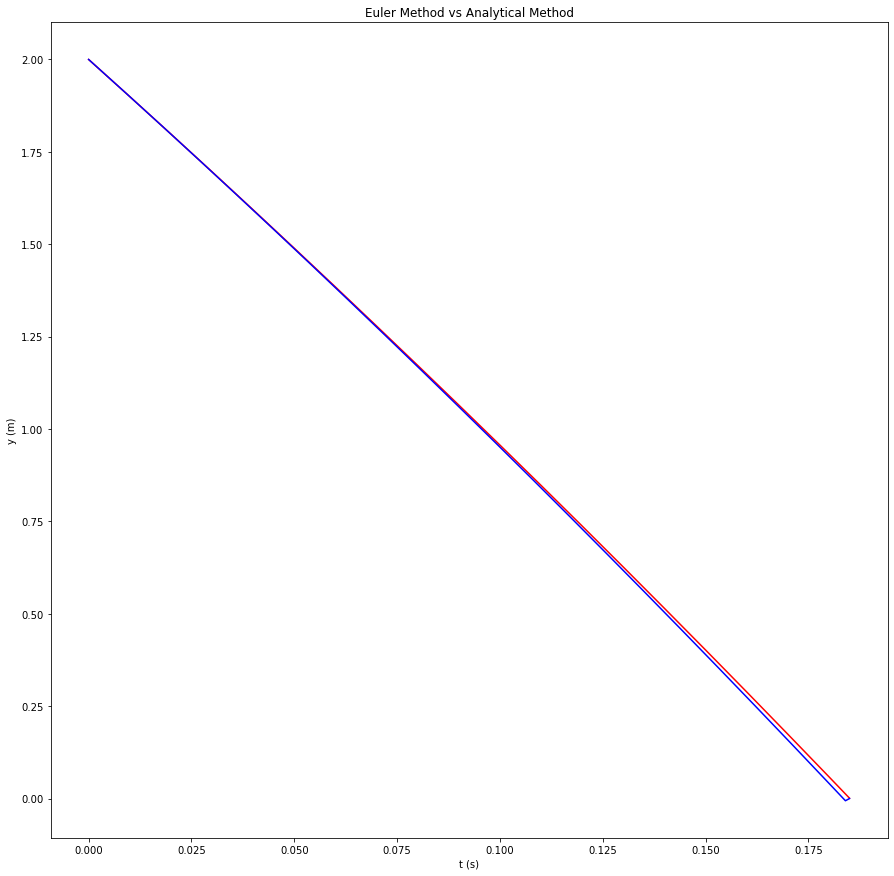

In [6]:
D = 0.002
m = 0.2
delta_t = 0.001
g = 9.81
tfinal = 0.186
n = int(tfinal/delta_t)
v_ter = np.sqrt(m*g/D)
t = np.zeros(n)
vx = np.zeros(n)
vy = np.zeros(n)
x = np.zeros(n)
y = np.zeros(n)
y_analytic = np.zeros(n)
vx[0]=10
vy[0]=10
y[0]=2
y_analytic[0]=2
x[0]=0
v = []
v.append(10)
for i in range(n-1):
    ax = -D/m*vx[i]*np.sqrt(vx[i]**2+vy[i+1]**2)
    ay = -D/m*vy[i]*np.sqrt(vx[i]**2+vy[i+1]**2)+g
    vx[i+1] = vx[i]+delta_t*ax
    vy[i+1] = vy[i]+delta_t*ay
    x[i+1] = x[i]+delta_t*vx[i]
    y[i+1] = y[i]-delta_t*vy[i]
    t[i+1] = t[i]+delta_t
    y_analytic[i] = y[0]-((v_ter**2/g))*np.log(np.cosh(g*t[i]/v_ter))-vy[0]*t[i]
    if (y[i+1]<0):
        break
plt.figure(figsize=(15,15))
plt.plot(t, y, label='Euler Method', color='r')
plt.plot(t, y_analytic, label='Analytical Method', color='b')
plt.xlabel('t (s)')
plt.ylabel('y (m)')
plt.title('Euler Method vs Analytical Method')

In [7]:
data = {'t (s)': t, 'Relative error in y': abs((y-y_analytic)/y_analytic), 'y (Euler)': y, 'y (Analytic)': y_analytic}
relative = pd.DataFrame(data)
relative

/var/folders/90/4q28dtpd5x55x38mlk6rf8w40000gn/T/ipykernel_33706/3049356170.py:1: RuntimeWarning: divide by zero encountered in true_divide
  data = {'t (s)': t, 'Relative error in y': abs((y-y_analytic)/y_analytic), 'y (Euler)': y, 'y (Analytic)': y_analytic}


,t (s),Relative error in y,y (Euler),y (Analytic)
0,0.000,0.000000,2.000000,2.000000
1,0.001,0.000002,1.990000,1.989995
2,0.002,0.000005,1.979991,1.979980
3,0.003,0.000009,1.969974,1.969956
4,0.004,0.000013,1.959947,1.959922
...,...,...,...,...
181,0.181,0.606970,0.047234,0.029393
182,0.182,1.023993,0.035652,0.017615
183,0.183,3.129750,0.024061,0.005826
184,0.184,3.086758,0.012462,-0.005972


**Here, it can be seen that the relative error between the euler-computed y position and the analytical y position continues to increase. This is also evident through the plot where the analytic plot slowly starts diverging from the euler plot. However, these errors can be minimized by taking smaller values of $\Delta t$, which would make the calculations more accurate. If we make more plots, we would see that as $\Delta t$ decreases, the numerical results would approach the analytical solution more closely. As $\Delta t$ increases, the numerical results would become less accurate, which is expected because Euler's method becomes less accurate for larger $\Delta t$ values. Further plots would show that the numerical results converge to the analytical solution as $\Delta t$ decreases, which would confirm the accuracy of the Euler's method.**

### Classical Mechanics Extra Credit Assignment: Scientific Writing and attending Talks

The following gives you an opportunity to earn **five extra credit
points** on each of the remaining homeworks and **ten extra credit points**
on the midterms and finals.  This assignment also covers an aspect of
the scientific process that is not taught in most undergraduate
programs: scientific writing.  Writing scientific reports is how
scientist communicate their results to the rest of the field.  Knowing
how to assemble a well written scientific report will greatly benefit
you in you upper level classes, in graduate school, and in the work
place.

The full information on extra credits is found at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>. There you will also find examples on how to write a scientific article. 
Below you can also find a description on how to gain extra credits by attending scientific talks.

This assignment allows you to gain extra credit points by practicing
your scientific writing.  For each of the remaining homeworks you can
submit the specified section of a scientific report (written about the
numerical aspect of the homework) for five extra credit points on the
assignment.  For the two midterms and the final, submitting a full
scientific report covering the numerical analysis problem will be
worth ten extra points.  For credit the grader must be able to tell
that you put effort into the assignment (i.e. well written, well
formatted, etc.).  If you are unfamiliar with writing scientific
reports, [see the information here](https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/IntroductionScientificWriting.md)

The following table explains what aspect of a scientific report is due
with which homework.  You can submit the assignment in any format you
like, in the same document as your homework, or in a different one.
Remember to cite any external references you use and include a
reference list.  There are no length requirements, but make sure what
you turn in is complete and through.  If you have any questions,
please contact Julie Butler at butler@frib.msu.edu.

<table class="dotable" border="1">
<thead>
<tr><th align="center">  HW/Project </th> <th align="center">Due Date</th> <th align="center">Extra Credit Assignment</th> </tr>
</thead>
<tbody>
<tr><td align="center">   HW 3             </td> <td align="center">   2-4         </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 4             </td> <td align="center">   2-11        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 5             </td> <td align="center">   2-18        </td> <td align="center">   Methods                    </td> </tr>
<tr><td align="center">   HW 6             </td> <td align="center">   3-18        </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 1**    </td> <td align="center">   **3-4**     </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 7             </td> <td align="center">   3-25        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 8             </td> <td align="center">   4-15        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 9             </td> <td align="center">   4-22        </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 2      </td> <td align="center">   ** _4-8_    </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 10            </td> <td align="center">   4-29        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   **Final**        </td> <td align="center">   **5-6**     </td> <td align="center">   *Full Written Report*      </td> </tr>
</tbody>
</table>

You can also gain extra credits if you attend scientific talks.
This is described here.

### Integrating Classwork With Research

This opportunity will allow you to earn up to 5 extra credit points on a Homework per week. These points can push you above 100% or help make up for missed exercises.
In order to earn all points you must:

1. Attend an MSU research talk (recommended research oriented Clubs is  provided below)

2. Summarize the talk using at least 150 words

3. Turn in the summary along with your Homework.

Approved talks:
Talks given by researchers through the following clubs:
* Research and Idea Sharing Enterprise (RAISE)​: Meets Wednesday Nights Society for Physics Students (SPS)​: Meets Monday Nights

* Astronomy Club​: Meets Monday Nights

* Facility For Rare Isotope Beam (FRIB) Seminars: ​Occur multiple times a week

If you have any questions please consult Julie or Morten

All the material on extra credits is at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>.